## Step 1: Problem Definition
This project aims to classify clinical trial diseases based on unstructured text data (brief summaries) into predefined categories. We use NLP techniques to extract features from the text and train a classification model.

In [1]:
import os
import re
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sqlalchemy import create_engine, Column, Integer, String, Text
from sqlalchemy.orm import declarative_base, sessionmaker
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import joblib
import warnings
warnings.filterwarnings('ignore')

## Step 2: Data Collection
We ingest the clinical trials data from a CSV file (or database) into a pandas dataframe to understand the dataset structure.

In [2]:
from dotenv import load_dotenv
from urllib.parse import quote_plus
load_dotenv()

db_user = os.getenv("DB_USER", "postgres")
db_password = os.getenv("DB_PASSWORD", "")
db_password_encoded = quote_plus(db_password) if db_password else ""
db_host = os.getenv("DB_HOST", "localhost")
db_port = os.getenv("DB_PORT", "5432")
db_name = os.getenv("DB_NAME", "clinical_trials_db")
db_url = f"postgresql://{db_user}:{db_password_encoded}@{db_host}:{db_port}/{db_name}"
db_url = os.getenv("DATABASE_URL", db_url)

engine = create_engine(db_url)

# Load data into pandas
csv_path = r"c:\Users\jegad\projects\Clinical Trial Disease Classification\data\clinical_trials_raw_patient2trial_conditions.csv"
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    df['brief_summary'] = df['brief_summary'].fillna("")
    df['title'] = df['title'].fillna(df['nct_id'])
    df['source_condition_query'] = df['source_condition_query'].fillna("other")
    df = df.rename(columns={'source_condition_query': 'disease_category'})
    print(f"Loaded {len(df)} raw records.")
else:
    print("CSV not found.")
    df = pd.DataFrame(columns=['brief_summary', 'disease_category'])

print("\nDataset Info:")
df.info()

print("\nFirst 5 rows:")
display(df.head())


Loaded 60337 raw records.

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60337 entries, 0 to 60336
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   disease_category      60337 non-null  object
 1   nct_id                60337 non-null  object
 2   title                 60337 non-null  object
 3   official_title        59551 non-null  object
 4   brief_summary         60337 non-null  object
 5   conditions            60336 non-null  object
 6   interventions         54276 non-null  object
 7   overall_status        60337 non-null  object
 8   study_type            60337 non-null  object
 9   phase                 23336 non-null  object
 10  sex                   60304 non-null  object
 11  minimum_age           57121 non-null  object
 12  maximum_age           28400 non-null  object
 13  healthy_volunteers    58857 non-null  object
 14  eligibility_criteria  60326 non-null  object


,disease_category,nct_id,title,official_title,brief_summary,conditions,interventions,overall_status,study_type,phase,sex,minimum_age,maximum_age,healthy_volunteers,eligibility_criteria,clinicaltrials_url
0,breast cancer,NCT03676114,Effect of Perioperative Low Dose Ketamine on P...,Effect of Perioperative Low Dose Ketamine on P...,Breast cancer patients often have perioperativ...,Breast Cancer,ketamine | Normal saline,UNKNOWN,INTERVENTIONAL,PHASE4,FEMALE,20 Years,65 Years,False,Inclusion Criteria:\n\n1. American Society of ...,https://clinicaltrials.gov/study/NCT03676114
1,breast cancer,NCT02941614,Implementing Systematic Distress Screening in ...,Implementing Systematic Distress Screening in ...,Many breast cancer patients experience psychol...,Breast Cancer,Distress screening,COMPLETED,OBSERVATIONAL,NaN,ALL,18 Years,NaN,False,Inclusion Criteria:\n\n* Newly diagnosed with ...,https://clinicaltrials.gov/study/NCT02941614
2,breast cancer,NCT04509063,Investigating Public Enthusiasm for Mammograph...,Investigating Public Enthusiasm for Mammograph...,"Based on an American study by Scherer et al., ...",Breast Neoplasm Female | Mammography Screening...,Information about hypothetical mammography scr...,COMPLETED,INTERVENTIONAL,NaN,FEMALE,44 Years,49 Years,True,Inclusion Criteria:\n\n* Residence: Central De...,https://clinicaltrials.gov/study/NCT04509063
3,breast cancer,NCT04327063,MIRs 04 : Interpectoral Nerve Block With Ropiv...,A Double-blind Randomized Trial of Interpector...,Compare the effect of ropivacaine versus place...,Malignant Neoplasm of Breast,Saline | Ropivacaine,COMPLETED,INTERVENTIONAL,PHASE3,FEMALE,18 Years,85 Years,False,Inclusion Criteria:\n\n1. Women with non-metas...,https://clinicaltrials.gov/study/NCT04327063
4,breast cancer,NCT06778863,A Study of CLSP-1025 in Adult Patients With So...,GUARDIAN-101: A Phase 1 Dose Escalation and Ex...,Phase 1 dose escalation and expansion study of...,Advanced Solid Tumor | Unresectable Solid Tumo...,CLSP-1025,RECRUITING,INTERVENTIONAL,PHASE1,ALL,18 Years,NaN,False,Key Inclusion Criteria:\n\n* Patients must be ...,https://clinicaltrials.gov/study/NCT06778863


## Step 3: Data Cleaning & Exploratory Data Analysis (EDA)
Handling missing values, deduplication, and visualizing text distributions and frequent keywords.

In [3]:
# Remove duplicates
initial_len = len(df)
df = df.drop_duplicates(subset=['nct_id']) if 'nct_id' in df.columns else df.drop_duplicates(subset=['brief_summary'])
print(f"Removed {initial_len - len(df)} duplicate records.")

# Encode target labels
label_encoder = LabelEncoder()
df['disease_category_encoded'] = label_encoder.fit_transform(df['disease_category'])
print("Classes:", label_encoder.classes_)

Removed 0 duplicate records.
Classes: ['anxiety' 'breast cancer' 'chronic obstructive pulmonary disease'
 'covid-19' 'glaucoma' 'rheumatoid arthritis' 'sickle cell anemia'
 'type 2 diabetes']


In [4]:
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text_fast(text_data):
    if not isinstance(text_data, str) or not text_data.strip(): return ""
    text_data = text_data.lower()
    text_data = re.sub(r'<[^>]*>', ' ', text_data)
    text_data = re.sub(r'[^a-z\s]', ' ', text_data)
    words = text_data.split()
    cleaned_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words and len(w) > 2]
    return " ".join(cleaned_words)

print("Preprocessing summaries...")
df['cleaned_summary'] = df['brief_summary'].apply(clean_text_fast)
df = df[df['cleaned_summary'].str.strip() != ""]
print(f"Total records after cleaning: {len(df)}")

Preprocessing summaries...


Total records after cleaning: 60337


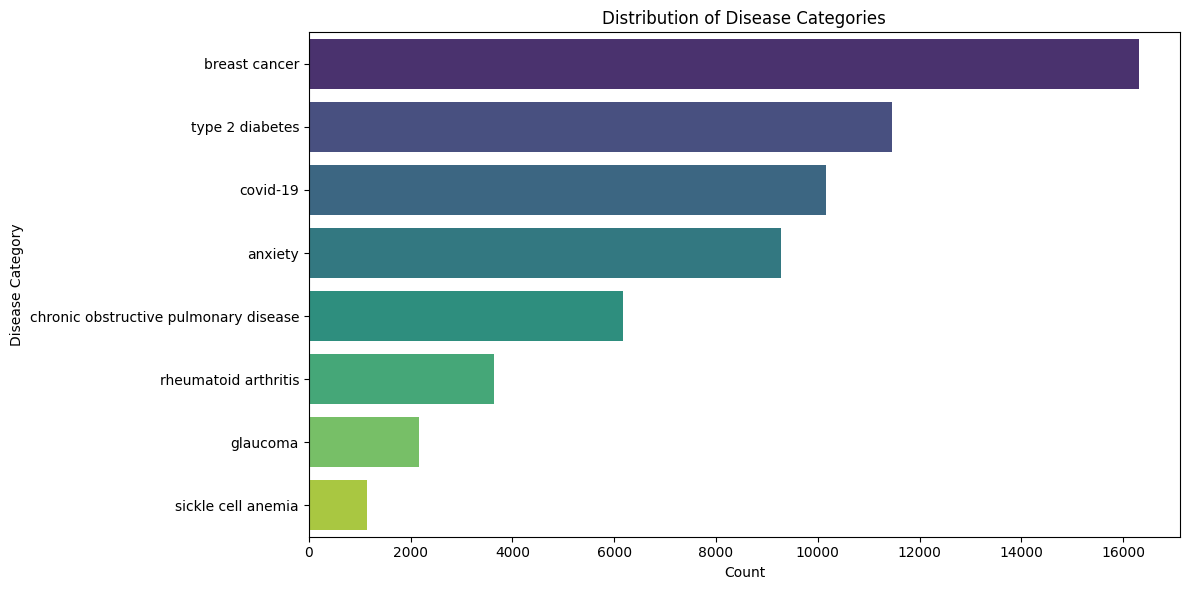

In [5]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='disease_category', order=df['disease_category'].value_counts().index, palette='viridis')
plt.title("Distribution of Disease Categories")
plt.xlabel("Count")
plt.ylabel("Disease Category")
plt.tight_layout()
plt.show()

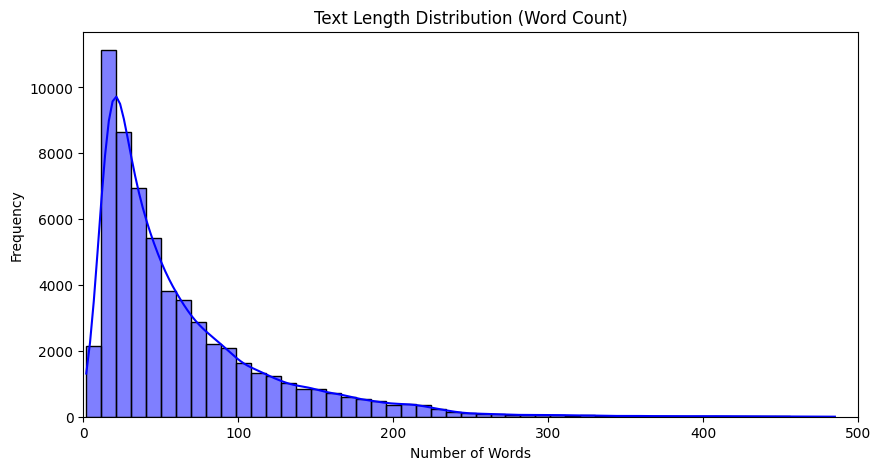

In [6]:
# Text Length Distribution
df['summary_word_count'] = df['cleaned_summary'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10, 5))
sns.histplot(df['summary_word_count'], bins=50, kde=True, color='blue')
plt.title("Text Length Distribution (Word Count)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.xlim(0, 500)
plt.show()

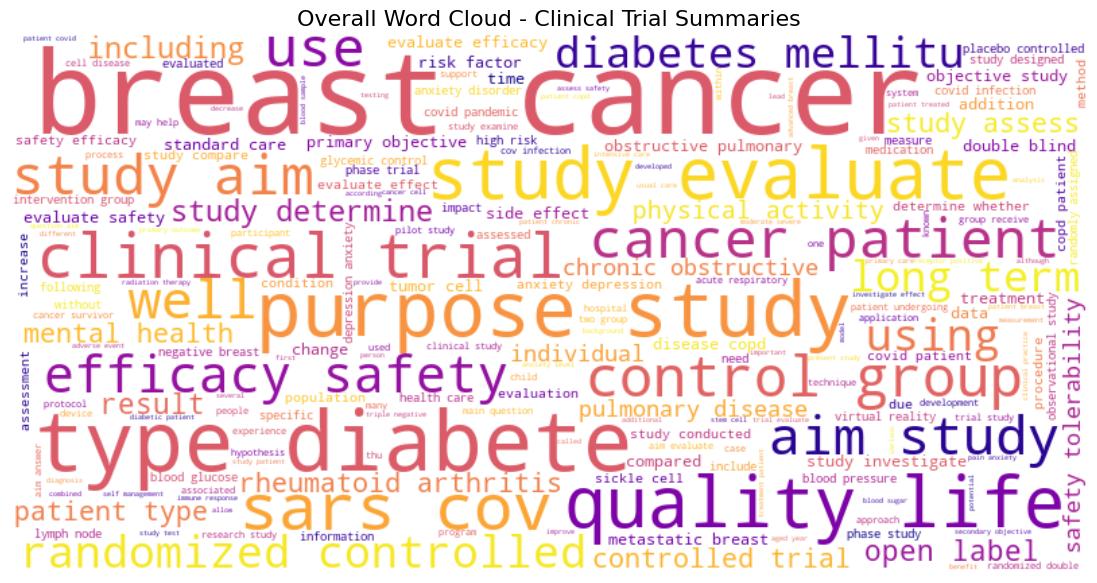

In [7]:
# Word Cloud for the Entire Corpus
combined_text = " ".join(df['cleaned_summary'].tolist())
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='plasma', max_words=200).generate(combined_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Overall Word Cloud - Clinical Trial Summaries", fontsize=16)
plt.show()

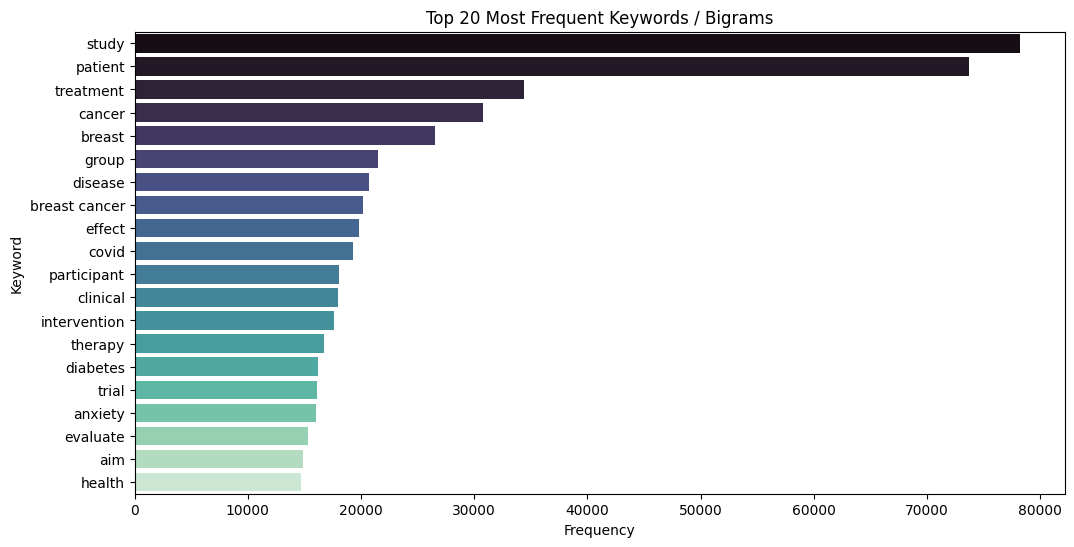

In [8]:
# Top 20 Most Frequent Words
vectorizer_eda = CountVectorizer(max_features=20, ngram_range=(1,2))
word_counts = vectorizer_eda.fit_transform(df['cleaned_summary'])
sum_words = word_counts.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer_eda.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

words, counts = zip(*words_freq)
plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts), y=list(words), palette='mako')
plt.title("Top 20 Most Frequent Keywords / Bigrams")
plt.xlabel("Frequency")
plt.ylabel("Keyword")
plt.show()

## Step 4: Feature Engineering
Using TF-IDF for vectorization to convert raw text into numerical features.

In [9]:
X = df['cleaned_summary'].values
y = df['disease_category_encoded'].values

tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1, 2), sublinear_tf=True)

## Step 5: Train-Test Split
Splitting the dataset into training and testing sets (80/20).

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {len(X_train)} | Test set size: {len(X_test)}")

Training set size: 48269 | Test set size: 12068


## Step 6: Model Selection
We instantiate three distinct algorithms commonly used for text classification:
1. **Logistic Regression**
2. **Multinomial Naive Bayes**
3. **Random Forest Classifier**

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
}

## Step 7: Model Training
Training all selected models using the TF-IDF pipeline.

In [12]:
results = {}
best_model_name = None
best_accuracy = 0
best_pipeline = None

for name, clf in models.items():
    print(f"Training {name}...")
    pipeline = Pipeline([('tfidf', tfidf), ('clf', clf)])
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    print(f"  -> Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_model_name = name
        best_pipeline = pipeline
        
print(f"\nBest Base Model: {best_model_name} with Accuracy: {best_accuracy:.4f}")

Training Logistic Regression...


  -> Accuracy: 0.9481 | Precision: 0.9496 | Recall: 0.9481 | F1: 0.9485
Training Multinomial Naive Bayes...


  -> Accuracy: 0.8977 | Precision: 0.9048 | Recall: 0.8977 | F1: 0.8980
Training Random Forest...


  -> Accuracy: 0.9415 | Precision: 0.9426 | Recall: 0.9415 | F1: 0.9413

Best Base Model: Logistic Regression with Accuracy: 0.9481


## Step 8: Model Evaluation
Comparing the results visually and displaying a detailed report for the best model.

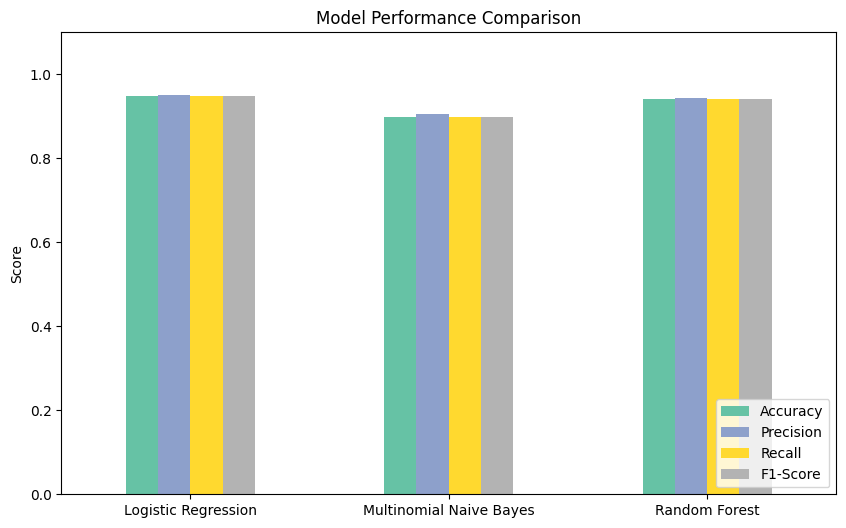

In [13]:
# Plot Model Comparison
metrics_df = pd.DataFrame(results).T
metrics_df.plot(kind='bar', figsize=(10, 6), colormap='Set2')
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.ylim(0, 1.1)
plt.show()

Classification Report for Logistic Regression:

                                       precision    recall  f1-score   support

                              anxiety       0.90      0.97      0.93      1857
                        breast cancer       0.98      0.96      0.97      3260
chronic obstructive pulmonary disease       0.91      0.92      0.92      1236
                             covid-19       0.98      0.94      0.96      2031
                             glaucoma       0.95      0.96      0.95       435
                 rheumatoid arthritis       0.87      0.93      0.90       727
                   sickle cell anemia       0.96      0.90      0.93       228
                      type 2 diabetes       0.96      0.95      0.96      2294

                             accuracy                           0.95     12068
                            macro avg       0.94      0.94      0.94     12068
                         weighted avg       0.95      0.95      0.95     12068



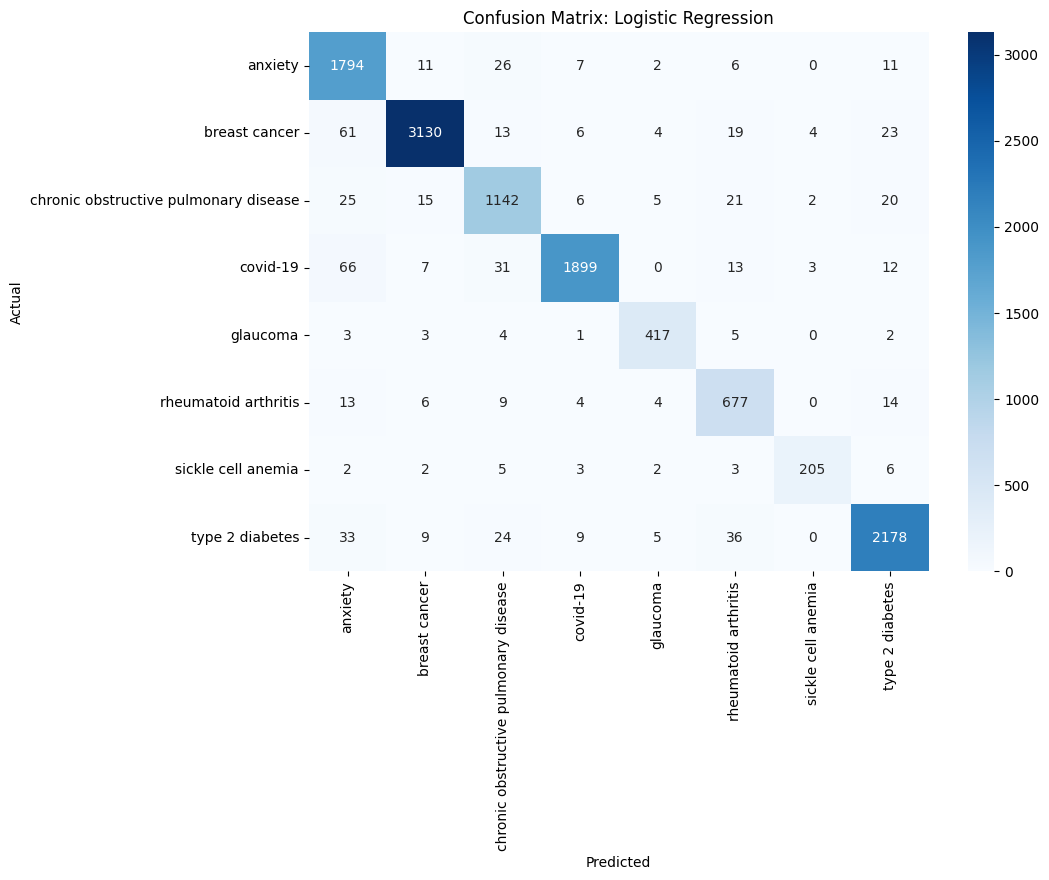

In [14]:
y_pred_best = best_pipeline.predict(X_test)
print(f"Classification Report for {best_model_name}:\n")
print(classification_report(y_test, y_pred_best, target_names=label_encoder.classes_, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Step 9: Model Tuning
We apply `GridSearchCV` on the top performing algorithm to squeeze out the best hyperparameters, and save the final pipeline to disk.

In [15]:
print(f"Tuning {best_model_name}...")

# Example param grid based on the winning model
if best_model_name == "Logistic Regression":
    param_grid = {'clf__C': [0.1, 1.0, 2.0]}
elif best_model_name == "Random Forest":
    param_grid = {'clf__n_estimators': [50, 100]}
else:
    param_grid = {'clf__alpha': [0.1, 1.0]}

grid_search = GridSearchCV(best_pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Tuned Test Accuracy: {accuracy_score(y_test, grid_search.best_estimator_.predict(X_test)):.4f}")

# Extract top predictive words based on the model architecture
final_pipeline = grid_search.best_estimator_
vectorizer = final_pipeline.named_steps['tfidf']
classifier = final_pipeline.named_steps['clf']
feature_names = vectorizer.get_feature_names_out()
classes = label_encoder.classes_

top_words_per_class = {}
for idx, class_name in enumerate(classes):
    top_words = []
    if hasattr(classifier, 'coef_'):
        if len(classes) == 2:
            coefs = classifier.coef_[0] if idx == 1 else -classifier.coef_[0]
        else:
            coefs = classifier.coef_[idx]
        top_coef_indices = np.argsort(coefs)[-20:][::-1]
        top_words = [(feature_names[i], float(coefs[i])) for i in top_coef_indices]
    elif hasattr(classifier, 'feature_log_prob_'):
        coefs = classifier.feature_log_prob_[idx]
        top_coef_indices = np.argsort(coefs)[-20:][::-1]
        top_words = [(feature_names[i], float(coefs[i])) for i in top_coef_indices]
    elif hasattr(classifier, 'feature_importances_'):
        coefs = classifier.feature_importances_
        top_coef_indices = np.argsort(coefs)[-20:][::-1]
        top_words = [(feature_names[i], float(coefs[i])) for i in top_coef_indices]
        
    top_words_per_class[class_name] = top_words

y_pred = final_pipeline.predict(X_test)
metrics = {
    'accuracy': float(accuracy_score(y_test, y_pred)),
    'classification_report': classification_report(y_test, y_pred, output_dict=True, zero_division=0),
    'confusion_matrix': confusion_matrix(y_test, y_pred).tolist(),
    'classes': classes.tolist(),
    'n_train_samples': int(len(X_train)),
    'n_test_samples': int(len(X_test)),
    'top_predictive_words': top_words_per_class
}

os.makedirs("models", exist_ok=True)
joblib.dump(final_pipeline, "models/classifier_pipeline.joblib")
joblib.dump(metrics, "models/training_metrics.joblib")
print("SUCCESS: Tuned model pipeline and metrics saved to models/ directory.")

Tuning Logistic Regression...


Best Parameters: {'clf__C': 2.0}


Tuned Test Accuracy: 0.9495


SUCCESS: Tuned model pipeline and metrics saved to models/ directory.


## Step 10: Model Deployment

The disease prediction system and end-user interface have been modularized.

This notebook has exported `models/classifier_pipeline.joblib` and `models/training_metrics.joblib`. 

The live prediction application is implemented in `app/app.py` using Streamlit. To run the web dashboard, simply execute:
```bash
streamlit run app/app.py
```

The application will load the finalized pipeline straight from disk, ensuring a clean separation between Machine Learning research and Production Deployment.